In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
df = df.drop_duplicates()
price = df['selling_price']
df['PriceClass'] = np.select([price < 250000, (price >= 250000) & (price < 600000), price >= 600000], [0, 1, 2])

X = df[['year', 'km_driven']].copy()
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    le = LabelEncoder()
    X[col + '_enc'] = le.fit_transform(df[col])
X = X[['year', 'km_driven', 'fuel_enc', 'seller_type_enc', 'transmission_enc', 'owner_enc']]
y = df['PriceClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Accuracy: 0.6885


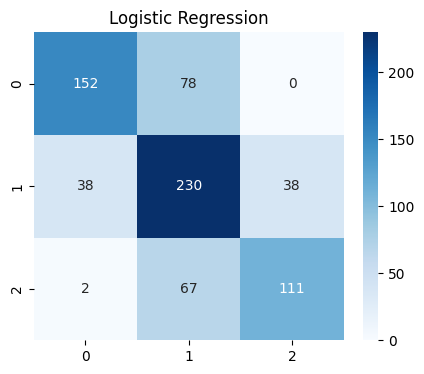

In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression')
plt.show()

Decision Tree Accuracy: 0.6941


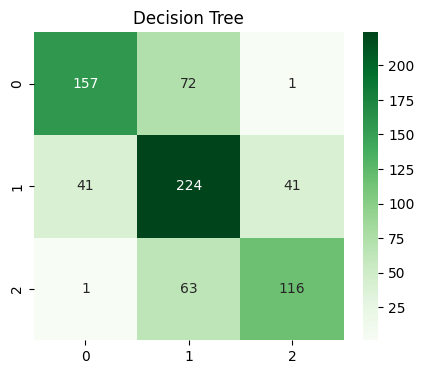

In [25]:
dt = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=5)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree')
plt.show()

SVM Accuracy: 0.6872


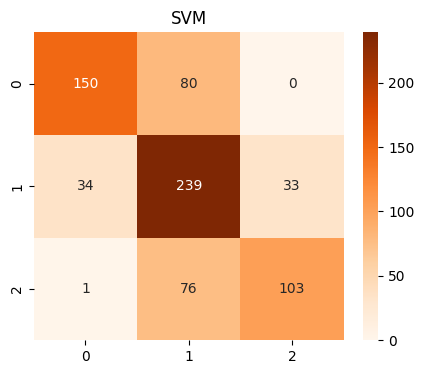

In [26]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
cm_svm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title('SVM')
plt.show()

PCA Variance: 0.5086


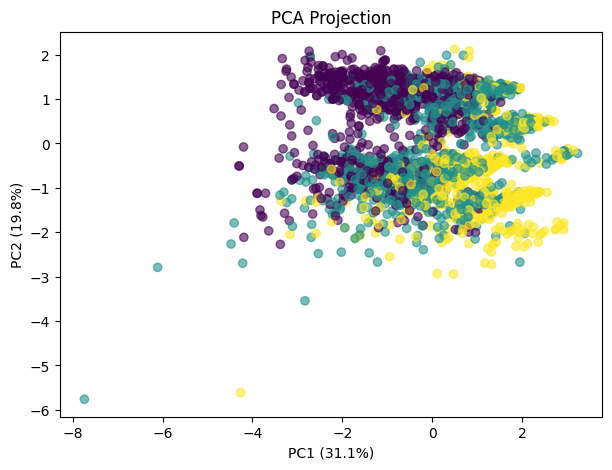

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
print(f"PCA Variance: {np.sum(pca.explained_variance_ratio_):.4f}")
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA Projection')
plt.show()

KMeans Clusters: [ 559 1088 1214]


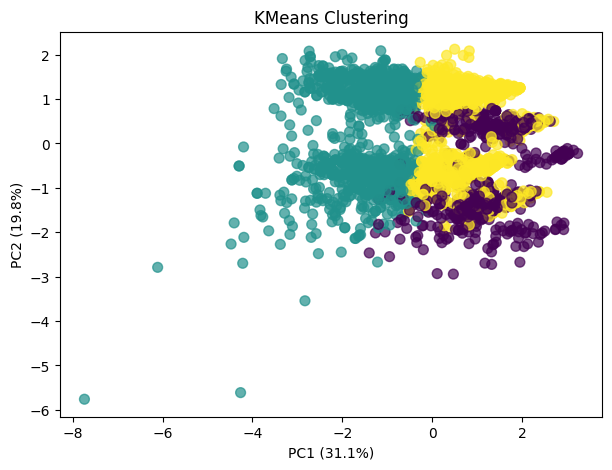

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)
print(f"KMeans Clusters: {np.bincount(clusters)}")
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('KMeans Clustering')
plt.show()


=== MODEL COMPARISON ===
Logistic Regression: 0.6885
Decision Tree: 0.6941
SVM: 0.6872
PCA Variance: 0.5086
KMeans Clusters: 3


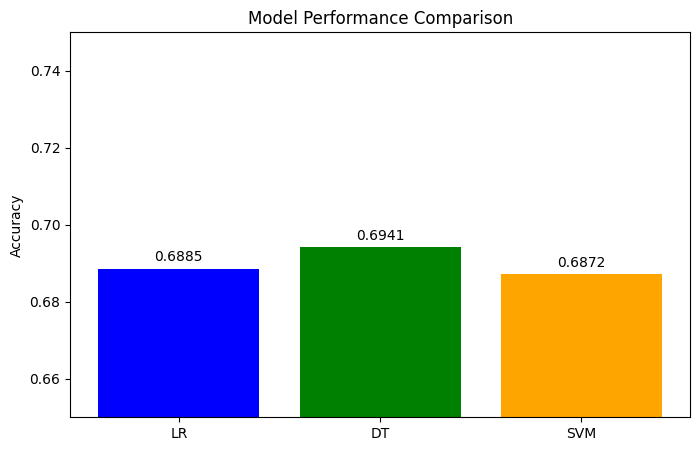

In [29]:
print("\n=== MODEL COMPARISON ===")
acc_lr = accuracy_score(y_test, lr_pred)
acc_dt = accuracy_score(y_test, dt_pred)
acc_svm = accuracy_score(y_test, svm_pred)
pca_var = np.sum(pca.explained_variance_ratio_)
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"Decision Tree: {acc_dt:.4f}")
print(f"SVM: {acc_svm:.4f}")
print(f"PCA Variance: {pca_var:.4f}")
print(f"KMeans Clusters: 3")

models = ['LR', 'DT', 'SVM']
accuracies = [acc_lr, acc_dt, acc_svm]
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim([0.65, 0.75])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')
plt.show()